# 07 — Cantilever beam (inverse PINN)

Recover both the deflection field $w(x)$ and the **Young's modulus**
$E$ from noisy displacement measurements. This is an *inverse*
problem: $E$ is a learnable scalar alongside the network weights.

**Governing equations** (Euler-Bernoulli, $I$ constant):

$$M(x) = E\,I\,w''(x), \qquad M''(x) = q(x).$$

**Boundary conditions** (cantilever, free at `x = L`):
  - $w(0) = 0,\; w'(0) = 0$ — enforced *hard* via the ansatz
    $w_\theta(x) = x^2 \tilde{w}_\theta(x)$.
  - $M(L) = 0,\; M'(L) = 0$ — enforced *soft* in the loss.

**Synthetic data**: 25 stations sampled from the exact deflection

$$w_{exact}(x) = \frac{q\,x^2}{24\,E\,I}\,(6L^2 - 4Lx + x^2)$$

with 1% Gaussian noise. **Target**: $E^* = 200$ GPa. The network's
title bar shows the recovered $E$.

**Stability tricks** worth noting:
  - learn $\log E$ (keeps $E > 0$ and improves the optimisation
    landscape);
  - displacement scale `w_scale = 1e-6` keeps targets close to unity;
  - loss weights `(50, 5, 1, 10)` balance data, constitutive,
    equilibrium, and free-end-BC residuals.

Refinement 0 | E = 239.81 GPa
Refinement 1 | E = 229.48 GPa
Refinement 2 | E = 211.34 GPa
Refinement 3 | E = 199.95 GPa
Refinement 4 | E = 195.96 GPa
Refinement 5 | E = 190.11 GPa
Refinement 6 | E = 188.49 GPa
Refinement 7 | E = 188.40 GPa
Refinement 8 | E = 187.98 GPa
Refinement 9 | E = 188.72 GPa


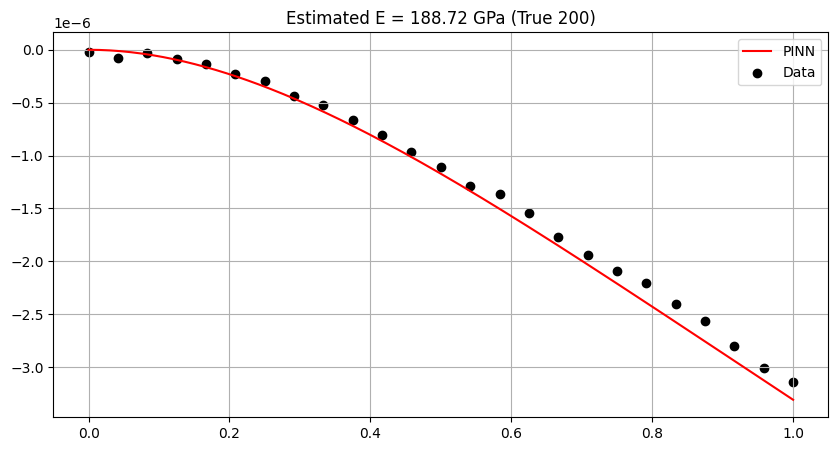

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# 1. Physical Parameters
# ===============================
L, I, q_val, E_true = 1.0, 1e-4, -500.0, 200e9
w_scale = 1e-6

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================
# 2. Stable PINN Architecture
# Outputs: w(x), M(x)
# ===============================
class StableBeamPINN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 2)   # w_tilde, M_tilde
        )

        # Learn log(E) for stability
        self.logE = nn.Parameter(torch.tensor([np.log(200e9)]))

    def forward(self, x):
        out = self.net(x)
        w_tilde = out[:, 0:1]
        M_tilde = out[:, 1:2]

        # Hard BC at clamped end: w(0)=0, w'(0)=0
        w = (x**2) * w_tilde

        # Moment free at tip will be enforced via loss
        M = M_tilde

        return w, M

    def get_E(self):
        return torch.exp(self.logE)

model = StableBeamPINN().to(device)

# ===============================
# 3. Synthetic Data (displacement)
# ===============================
def get_data():
    x = np.linspace(0, L, 25)
    w = (q_val * x**2) / (24 * E_true * I) * (6*L**2 - 4*L*x + x**2)

    noise = 0.01 * np.max(np.abs(w)) * np.random.randn(*w.shape)
    w_noisy = w + noise

    x_t = torch.tensor(x, dtype=torch.float32).view(-1,1).to(device)
    w_t = torch.tensor(w_noisy, dtype=torch.float32).view(-1,1).to(device)

    return x_t, w_t

x_data, w_data = get_data()

# ===============================
# 4. Deterministic Collocation
# ===============================
x_phys = torch.linspace(0, L, 200).view(-1,1).to(device)
x_phys.requires_grad_(True)

# ===============================
# 5. Stable Loss Function
# ===============================
def closure():
    optimizer.zero_grad()

    w, M = model(x_phys)
    w = w * w_scale
    E = model.get_E()

    # ----- derivatives -----
    dw = torch.autograd.grad(w, x_phys, torch.ones_like(w), create_graph=True)[0]
    dw2 = torch.autograd.grad(dw, x_phys, torch.ones_like(dw), create_graph=True)[0]

    dM = torch.autograd.grad(M, x_phys, torch.ones_like(M), create_graph=True)[0]
    dM2 = torch.autograd.grad(dM, x_phys, torch.ones_like(dM), create_graph=True)[0]

    # ===============================
    # Physics equations
    # ===============================

    # M = EI w''
    loss_constitutive = torch.mean((M - E * I * dw2)**2)

    # M'' = q
    loss_equilibrium = torch.mean((dM2 - q_val)**2)

    # ===============================
    # Data loss
    # ===============================
    w_pred_data, _ = model(x_data)
    w_pred_data = w_pred_data * w_scale

    loss_data = torch.mean((w_pred_data - w_data)**2) / (w_scale**2)

    # ===============================
    # Boundary conditions at free end x=L
    # M(L)=0, V(L)=M'(L)=0
    # ===============================
    xL = torch.tensor([[L]], dtype=torch.float32).to(device)
    xL.requires_grad_(True)

    _, ML = model(xL)

    dML = torch.autograd.grad(ML, xL, torch.ones_like(ML), create_graph=True)[0]

    loss_bc = ML.pow(2).mean() + dML.pow(2).mean()

    # ===============================
    # Total Loss (balanced)
    # ===============================
    total_loss = (
        50 * loss_data
        + 5  * loss_constitutive
        + 1  * loss_equilibrium
        + 10 * loss_bc
    )

    total_loss.backward()
    return total_loss

# ===============================
# 6. Training
# ===============================
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for i in range(4000):
    optimizer.step(closure)

# L-BFGS refinement
optimizer = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=50)

for i in range(10):
    optimizer.step(closure)
    print(f"Refinement {i} | E = {model.get_E().item()/1e9:.2f} GPa")

# ===============================
# 7. Results
# ===============================
model.eval()
with torch.no_grad():
    x_test = torch.linspace(0, L, 200).view(-1,1).to(device)
    w_pred, _ = model(x_test)
    w_pred = w_pred * w_scale

    plt.figure(figsize=(10,5))
    plt.plot(x_test.cpu(), w_pred.cpu(), 'r-', label='PINN')
    plt.scatter(x_data.cpu(), w_data.cpu(), c='k', label='Data')
    plt.title(f"Estimated E = {model.get_E().item()/1e9:.2f} GPa (True 200)")
    plt.legend()
    plt.grid(True)
    plt.show()

Refinement 0 | E = 189.47 GPa
Refinement 1 | E = 189.07 GPa
Refinement 2 | E = 190.14 GPa
Refinement 3 | E = 194.12 GPa
Refinement 4 | E = 197.26 GPa
Refinement 5 | E = 198.68 GPa
Refinement 6 | E = 199.67 GPa
Refinement 7 | E = 200.87 GPa
Refinement 8 | E = 200.71 GPa
Refinement 9 | E = 201.44 GPa


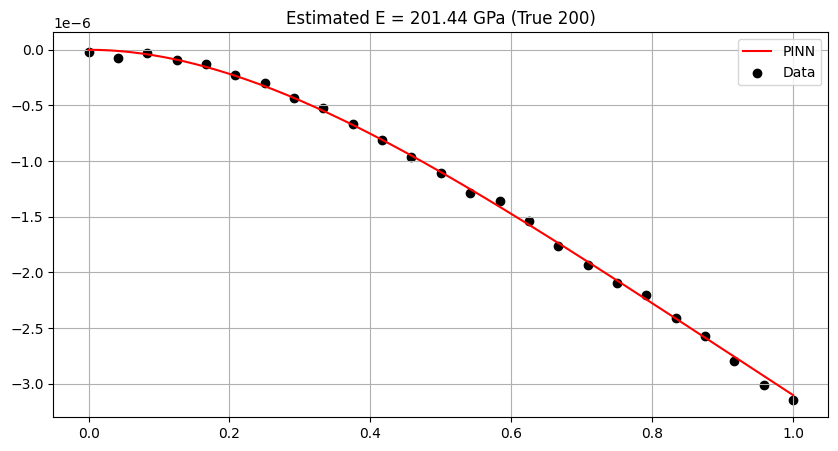

In [2]:
for i in range(10):
    optimizer.step(closure)
    print(f"Refinement {i} | E = {model.get_E().item()/1e9:.2f} GPa")

# ===============================
# 7. Results
# ===============================
model.eval()
with torch.no_grad():
    x_test = torch.linspace(0, L, 200).view(-1,1).to(device)
    w_pred, _ = model(x_test)
    w_pred = w_pred * w_scale

    plt.figure(figsize=(10,5))
    plt.plot(x_test.cpu(), w_pred.cpu(), 'r-', label='PINN')
    plt.scatter(x_data.cpu(), w_data.cpu(), c='k', label='Data')
    plt.title(f"Estimated E = {model.get_E().item()/1e9:.2f} GPa (True 200)")
    plt.legend()
    plt.grid(True)
    plt.show()

In [3]:
# Quantitative error: recovered E and shape error vs the exact analytical solution
import numpy as np
E_pred = model.get_E().item()
print(f'True E      = {E_true/1e9:.3f} GPa')
print(f'Recovered E = {E_pred/1e9:.3f} GPa')
print(f'rel. error  = {abs(E_pred - E_true)/E_true:.3e}')
with torch.no_grad():
    x_eval = torch.linspace(0, L, 200, device=device).view(-1,1)
    w_pred, _ = model(x_eval)
    w_pred = (w_pred * w_scale).cpu().numpy().ravel()
x_np = x_eval.cpu().numpy().ravel()
w_ex = (q_val * x_np**2) / (24 * E_true * I) * (6*L**2 - 4*L*x_np + x_np**2)
rel_l2 = np.linalg.norm(w_pred - w_ex) / np.linalg.norm(w_ex)
print(f'shape rel. L2 error = {rel_l2:.3e}')


True E      = 200.000 GPa
Recovered E = 201.440 GPa
rel. error  = 7.202e-03
shape rel. L2 error = 7.102e-03
